# Notebook 05 — Pipeline Hybride : Règles + ML + Analyse Headers
**Projet :** Système Intelligent de Détection de Spam et de Phishing  
**Auteur :** Nghogué Taptué Franck Roddier — 5GI, ENSPY  
**Semaine :** 3 / 3  
**Entrées :** `data/best_model.pkl`, `data/distilbert_model/`, `data/tfidf_vectorizer.pkl`  
**Sorties :** `data/pipeline_hybride.pkl`, `data/05_pipeline_results.json`

---

## Principe du pipeline hybride (§5.4 du cahier de charges)

Un seul modèle ML — aussi bon soit-il — a des angles morts :
- **TF-IDF + LinearSVC** : aveugle au contexte sémantique, ignore les headers
- **DistilBERT** : lent, ignore aussi les métadonnées réseau (IP, DNS, SPF)
- **Règles heuristiques seules** : facilement contournables par obfuscation

L'approche hybride combine les trois couches :

```
Email entrant
  │
  ├── Couche 1 : Règles heuristiques rapides
  │     → Filtrage immédiat des cas évidents (spam massif, URLs blacklistées)
  │     → Si confiance > 0.95 : décision directe (pas besoin du ML)
  │
  ├── Couche 2 : Analyse des headers & réputation réseau
  │     → SPF / DKIM / DMARC
  │     → Réputation IP expéditeur
  │     → Cohérence domaine From/Reply-To
  │
  ├── Couche 3 : Modèles ML (LinearSVC + DistilBERT optionnel)
  │     → Score TF-IDF + features structurelles
  │     → Vote pondéré si DistilBERT disponible
  │
  └── Agrégation finale
        → Score de confiance global [0, 1]
        → Classe prédite + niveau de menace
        → Déclenchement alerte si menace (§6.4)
```

## Objectifs
1. Construire chaque couche du pipeline
2. Implémenter le système de score de confiance agrégé
3. Tester sur des cas réels variés (y compris adversariaux)
4. Mesurer la latence globale du pipeline
5. Sauvegarder le pipeline complet pour l'API (NB 06)

## 0. Installation & imports

In [1]:
!pip install scikit-learn transformers torch pandas numpy matplotlib seaborn joblib tqdm dnspython requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 9.9 MB/s eta 0:00:00


In [2]:
import os
from pathlib import Path
from google.colab import drive

# 1. Monter le drive
drive.mount('/content/drive')

# 2. Se déplacer dans le dossier du projet
# Remplace par le chemin exact de ton dossier
os.chdir('/content/drive/MyDrive/notebooks')

# 3. Vérifier que le dossier 'data' est bien là
DATA_DIR = Path('data')
if DATA_DIR.exists():
    print("Dossier data trouvé !")
else:
    print("Dossier data introuvable. Contenu actuel :", os.listdir())

Mounted at /content/drive
Dossier data trouvé !


In [3]:
import re
import json
import html
import email
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from time import time
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional
from urllib.parse import urlparse
from scipy.sparse import hstack, csr_matrix

import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_DIR  = Path('data')
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CLASS_COLORS = {'ham': '#1D9E75', 'spam': '#D85A30', 'phishing': '#BA7517'}
CLASS_NAMES  = ['ham', 'phishing', 'spam']   # ordre alphabétique = ordre LabelEncoder

print(f'Device : {DEVICE}')
print('Environnement prêt.')

Device : cuda
Environnement prêt.


## 1. Chargement des modèles

In [4]:
# ---- Modèle ML classique (LinearSVC — NB 03) ----
ml_model      = joblib.load(DATA_DIR / 'best_model.pkl')
tfidf         = joblib.load(DATA_DIR / 'tfidf_vectorizer.pkl')
label_encoder = joblib.load(DATA_DIR / 'label_encoder.pkl')
CLASS_NAMES   = list(label_encoder.classes_)
N_CLASSES     = len(CLASS_NAMES)

print(f'Modèle ML chargé : {type(ml_model).__name__}')
print(f'Classes          : {CLASS_NAMES}')

# ---- Modèle DistilBERT (NB 04) ----
BERT_DIR = DATA_DIR / 'distilbert_model'
USE_BERT = BERT_DIR.exists() and len(list(BERT_DIR.glob('*.json'))) > 0

if USE_BERT:
    print('\nChargement de DistilBERT...')
    bert_tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_DIR)
    bert_model     = DistilBertForSequenceClassification.from_pretrained(BERT_DIR)
    bert_model     = bert_model.to(DEVICE)
    bert_model.eval()
    print('DistilBERT chargé.')
else:
    print('\nDistilBERT non trouvé → pipeline fonctionnera sans BERT (couche 3 = LinearSVC seul).')
    bert_tokenizer = None
    bert_model     = None

Modèle ML chargé : RandomForestClassifier
Classes          : ['ham', 'phishing', 'spam']

Chargement de DistilBERT...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT chargé.


## 2. Structures de données du pipeline

In [5]:
@dataclass
class AnalysisResult:
    """
    Résultat complet d'analyse d'un email par le pipeline hybride.
    Chaque couche contribue à la décision finale.
    """
    # Décision finale
    predicted_class:    str   = 'ham'
    threat_level:       str   = 'none'        # none / low / medium / high / critical
    global_confidence:  float = 0.0

    # Scores par couche
    rule_score:         float = 0.0           # 0 = aucun signal / 1 = spam/phishing certain
    header_score:       float = 0.0           # idem
    ml_proba:           dict  = field(default_factory=dict)
    bert_proba:         dict  = field(default_factory=dict)

    # Détails
    rules_triggered:    list  = field(default_factory=list)
    header_flags:       list  = field(default_factory=list)
    url_flags:          list  = field(default_factory=list)

    # Performance
    latency_ms:         float = 0.0
    decision_path:      str   = ''            # Trace du chemin de décision

    def to_dict(self) -> dict:
        return {
            'predicted_class':   self.predicted_class,
            'threat_level':      self.threat_level,
            'global_confidence': round(self.global_confidence, 4),
            'rule_score':        round(self.rule_score, 4),
            'header_score':      round(self.header_score, 4),
            'ml_proba':          {k: round(v, 4) for k, v in self.ml_proba.items()},
            'bert_proba':        {k: round(v, 4) for k, v in self.bert_proba.items()},
            'rules_triggered':   self.rules_triggered,
            'header_flags':      self.header_flags,
            'url_flags':         self.url_flags,
            'latency_ms':        round(self.latency_ms, 2),
            'decision_path':     self.decision_path,
        }

print('Structure AnalysisResult définie.')

Structure AnalysisResult définie.


## 3. Couche 1 — Règles heuristiques

Les règles heuristiques filtrent rapidement les cas évidents sans appel au modèle ML. Avantage : < 1ms, pas de GPU requis. Les règles couvrent les techniques d'attaque §1.1 du cahier de charges (obfuscation, caractères invisibles, IP brutes).

In [6]:
# Listes noires (exemples — à enrichir avec des sources externes en production)
BLACKLISTED_TLDS = {
    'xyz', 'info', 'biz', 'club', 'online', 'site', 'top', 'win',
    'gq', 'tk', 'ml', 'ga', 'cf', 'pw', 'cc', 'ws', 'icu', 'live',
    'click', 'link', 'loan', 'work', 'men', 'download', 'stream'
}

IMPERSONATED_BRANDS = [
    'paypal', 'amazon', 'microsoft', 'apple', 'google', 'netflix',
    'facebook', 'instagram', 'dhl', 'fedex', 'ups', 'irs', 'bank',
    'secure', 'login', 'verify', 'account', 'update', 'confirm',
    'coinbase', 'binance', 'blockchain', 'zoom', 'docusign'
]

SPAM_KEYWORDS = [
    'click here', 'act now', 'limited time', 'free gift', 'you won',
    'congratulations', 'claim your', 'no prescription', 'weight loss',
    'make money', 'work from home', 'earn cash', 'million dollar',
    'casino', 'enlargement', 'viagra', 'cialis', 'guaranteed return',
    'double your', 'wire transfer', 'western union', 'nigerian prince'
]

PHISHING_KEYWORDS = [
    'verify your account', 'confirm your identity', 'suspended',
    'unusual activity', 'security alert', 'update your password',
    'click to verify', 'your account will be', 'immediately',
    'within 24 hours', 'failure to', 'unauthorized access'
]


def apply_heuristic_rules(text: str) -> tuple[float, float, list, list]:
    """
    Applique les règles heuristiques sur le texte d'un email.

    Retourne :
        spam_score    : [0, 1] — probabilité spam selon les règles
        phishing_score: [0, 1] — probabilité phishing selon les règles
        rules_hit     : liste des règles déclenchées
        url_flags     : anomalies URL détectées
    """
    if not isinstance(text, str):
        return 0.0, 0.0, [], []

    text_lower = text.lower()
    rules_hit  = []
    url_flags  = []
    spam_pts   = 0.0
    phish_pts  = 0.0

    # ── Indicateurs SPAM ──────────────────────────────────────────
    excl_count = text.count('!')
    if excl_count >= 3:
        spam_pts += min(excl_count * 0.05, 0.25)
        rules_hit.append(f'exclamation_x{excl_count}')

    alpha_chars = [c for c in text if c.isalpha()]
    up_ratio    = sum(1 for c in alpha_chars if c.isupper()) / max(len(alpha_chars), 1)
    if up_ratio > 0.3:
        spam_pts += 0.2
        rules_hit.append(f'uppercase_ratio_{up_ratio:.0%}')

    dollar_count = text.count('$')
    if dollar_count >= 2:
        spam_pts += 0.15
        rules_hit.append(f'dollar_signs_x{dollar_count}')

    for kw in SPAM_KEYWORDS:
        if kw in text_lower:
            spam_pts += 0.1
            rules_hit.append(f'spam_kw:{kw}')

    # ── Indicateurs PHISHING ──────────────────────────────────────
    urls = re.findall(r'https?://[^\s<>"]+', text)

    for url in urls:
        try:
            parsed   = urlparse(url)
            hostname = parsed.netloc.lower()

            # IP brute dans l'URL
            if re.match(r'^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', hostname):
                phish_pts += 0.4
                url_flags.append(f'ip_url:{url[:60]}')

            # TLD suspect
            tld = hostname.rsplit('.', 1)[-1] if '.' in hostname else ''
            if tld in BLACKLISTED_TLDS:
                phish_pts += 0.25
                url_flags.append(f'suspicious_tld:.{tld}')

            # Marque usurpée dans le domaine
            for brand in IMPERSONATED_BRANDS:
                if brand in hostname and brand not in ['secure', 'login', 'verify', 'account']:
                    # Vrai domaine de la marque ?
                    is_real = hostname.endswith(f'{brand}.com') or hostname == f'{brand}.com'
                    if not is_real:
                        phish_pts += 0.3
                        url_flags.append(f'brand_impersonation:{brand}@{hostname}')
                        break

            # @ dans l'URL (obfuscation)
            if '@' in parsed.netloc:
                phish_pts += 0.35
                url_flags.append('at_in_url')

            # Sous-domaines excessifs (ex: login.secure.verify.example.xyz)
            subdomain_count = hostname.count('.') - 1
            if subdomain_count >= 3:
                phish_pts += 0.2
                url_flags.append(f'excessive_subdomains:{subdomain_count}')

        except Exception:
            pass

    # Mots-clés phishing dans le corps
    for kw in PHISHING_KEYWORDS:
        if kw in text_lower:
            phish_pts += 0.08
            rules_hit.append(f'phish_kw:{kw}')

    # Caractères invisibles / obfuscation Unicode (§1.1)
    invisible_chars = sum(1 for c in text if ord(c) in range(0x200B, 0x200F))
    if invisible_chars > 0:
        phish_pts += 0.4
        rules_hit.append(f'invisible_chars_x{invisible_chars}')

    # Normalisation [0, 1]
    spam_score    = min(spam_pts, 1.0)
    phishing_score = min(phish_pts, 1.0)

    return spam_score, phishing_score, rules_hit, url_flags


# Test rapide
test_text = 'URGENT!!! Verify your PayPal account NOW at http://paypa1-secure.xyz/login or it will be SUSPENDED!!!'
s, p, rules, urls = apply_heuristic_rules(test_text)
print(f'Test : spam_score={s:.2f}  phishing_score={p:.2f}')
print(f'Règles : {rules}')
print(f'URL flags : {urls}')

Test : spam_score=0.25  phishing_score=0.33
Règles : ['exclamation_x6', 'phish_kw:suspended']
URL flags : ['suspicious_tld:.xyz']


## 4. Couche 2 — Analyse des headers & réputation réseau

Implémentation des fonctionnalités §6.1 et §6.2 du cahier de charges : analyse SPF/DKIM/DMARC et détection du spoofing.

In [7]:
def parse_email_headers(raw_email: str) -> dict:
    """
    Parse les headers d'un email brut et extrait les informations
    utiles pour la détection de spoofing (§6.2).
    """
    try:
        msg = email.message_from_string(raw_email)
    except Exception:
        return {}

    headers = {
        'from':         msg.get('From', ''),
        'reply_to':     msg.get('Reply-To', ''),
        'return_path':  msg.get('Return-Path', ''),
        'received':     msg.get_all('Received', []),
        'spf':          msg.get('Received-SPF', ''),
        'dkim':         msg.get('DKIM-Signature', ''),
        'dmarc':        msg.get('Authentication-Results', ''),
        'x_mailer':     msg.get('X-Mailer', ''),
        'message_id':   msg.get('Message-ID', ''),
    }
    return headers


def extract_domain(address: str) -> str:
    """Extrait le domaine d'une adresse email."""
    match = re.search(r'@([\w.-]+)', address)
    return match.group(1).lower() if match else ''


def analyze_headers(raw_email: str) -> tuple[float, list]:
    """
    Analyse les headers d'un email et retourne un score de suspicion
    ainsi que la liste des indicateurs détectés.

    Retourne :
        header_score : [0, 1] — 0=légitime, 1=très suspect
        flags        : liste des anomalies détectées
    """
    headers = parse_email_headers(raw_email)
    if not headers:
        return 0.0, ['no_headers_parsed']

    flags = []
    score = 0.0

    from_domain    = extract_domain(headers.get('from', ''))
    reply_domain   = extract_domain(headers.get('reply_to', ''))
    return_domain  = extract_domain(headers.get('return_path', ''))

    # ── Vérification SPF ──────────────────────────────────────────
    spf = headers.get('spf', '').lower()
    if 'fail' in spf or 'softfail' in spf:
        score += 0.35
        flags.append('spf_fail')
    elif 'pass' in spf:
        score -= 0.1   # Bonus légitimité
        flags.append('spf_pass')
    elif not spf:
        score += 0.1
        flags.append('spf_missing')

    # ── Vérification DKIM ─────────────────────────────────────────
    dkim = headers.get('dkim', '')
    if not dkim:
        score += 0.15
        flags.append('dkim_missing')
    else:
        flags.append('dkim_present')

    # ── Vérification DMARC ────────────────────────────────────────
    dmarc = headers.get('dmarc', '').lower()
    if 'dmarc=fail' in dmarc:
        score += 0.4
        flags.append('dmarc_fail')
    elif 'dmarc=pass' in dmarc:
        score -= 0.15
        flags.append('dmarc_pass')

    # ── Détection spoofing : incohérence From / Reply-To ─────────
    if reply_domain and from_domain and reply_domain != from_domain:
        score += 0.3
        flags.append(f'domain_mismatch:from={from_domain},reply={reply_domain}')

    # ── Return-Path incohérent ────────────────────────────────────
    if return_domain and from_domain and return_domain != from_domain:
        score += 0.2
        flags.append(f'return_path_mismatch:{return_domain}')

    # ── Domaine expéditeur suspect ────────────────────────────────
    if from_domain:
        tld = from_domain.rsplit('.', 1)[-1] if '.' in from_domain else ''
        if tld in BLACKLISTED_TLDS:
            score += 0.25
            flags.append(f'sender_suspicious_tld:.{tld}')

    # ── IP dans Message-ID (signe de spam tool) ───────────────────
    msg_id = headers.get('message_id', '')
    if re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', msg_id):
        score += 0.15
        flags.append('ip_in_message_id')

    return max(0.0, min(score, 1.0)), flags


# Test avec un email simulé
SAMPLE_EMAIL_PHISHING = """From: security@paypa1-secure.xyz
Reply-To: collect@hacker-domain.cc
Return-Path: <bounce@different-domain.tk>
Subject: Your account has been suspended
Received-SPF: softfail (domain of paypa1-secure.xyz does not designate permitted sender hosts)
Message-ID: <192.168.1.100.phishing@xyz>

Dear customer, your PayPal account has been suspended.
Please verify at http://paypa1-secure.xyz/login immediately."""

h_score, h_flags = analyze_headers(SAMPLE_EMAIL_PHISHING)
print(f'Score headers : {h_score:.2f}')
print(f'Flags         : {h_flags}')

Score headers : 1.00
Flags         : ['spf_fail', 'dkim_missing', 'domain_mismatch:from=paypa1-secure.xyz,reply=hacker-domain.cc', 'return_path_mismatch:different-domain.tk', 'sender_suspicious_tld:.xyz', 'ip_in_message_id']


## 5. Couche 3 — Modèles ML

In [8]:
# Réutilisation du pipeline de nettoyage du NB 02
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
_RE_HTML   = re.compile(r'<[^>]+')
_RE_URL    = re.compile(r'https?://\S+|www\.\S+')
_RE_EMAIL  = re.compile(r'[\w.+-]+@[\w-]+\.[\w.]+')
_RE_NUM    = re.compile(r'\b\d+\b')
_RE_PUNCT  = re.compile(r'[^\w\s]')

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = html.unescape(text)
    text = _RE_HTML.sub(' ', text)
    text = _RE_URL.sub(' urltoken ', text)
    text = _RE_EMAIL.sub(' emailtoken ', text)
    text = text.lower()
    text = _RE_NUM.sub(' numtoken ', text)
    text = _RE_PUNCT.sub(' ', text)
    tokens = [
        LEMMATIZER.lemmatize(t) for t in text.split()
        if t not in STOP_WORDS or t in ('urltoken', 'emailtoken')
    ]
    return ' '.join(t for t in tokens if len(t) >= 2)


SUSPICIOUS_TLDS_FE = BLACKLISTED_TLDS   # réutilisation

def extract_structural_features(text: str) -> dict:
    """Extrait les features structurelles (identique NB 02)."""
    urls  = re.findall(r'https?://[^\s<>"]+', text)
    words = text.split()
    alpha = [c for c in text if c.isalpha()]

    ip_url = sum(
        1 for u in urls
        if re.search(r'https?://\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', u)
    )
    susp_tld = sum(
        1 for u in urls
        if urlparse(u).netloc.rsplit('.', 1)[-1] in SUSPICIOUS_TLDS_FE
    )

    return {
        'url_count':           len(urls),
        'has_ip_url':          int(ip_url > 0),
        'has_suspicious_tld':  int(susp_tld > 0),
        'has_brand_in_url':    int(any(b in u.lower() for u in urls for b in IMPERSONATED_BRANDS)),
        'url_max_length':      max((len(u) for u in urls), default=0),
        'url_avg_length':      float(np.mean([len(u) for u in urls])) if urls else 0.0,
        'url_subdomain_count': float(np.mean([urlparse(u).netloc.count('.') - 1 for u in urls])) if urls else 0.0,
        'has_at_in_url':       int(any('@' in u for u in urls)),
        'url_digit_ratio':     sum(c.isdigit() for u in urls for c in u) / max(sum(len(u) for u in urls), 1),
        'url_special_char':    sum(len(re.findall(r'[%@#!$&*]', u)) for u in urls),
        'char_count':          len(text),
        'word_count':          len(words),
        'exclamation_count':   text.count('!'),
        'question_count':      text.count('?'),
        'dollar_count':        text.count('$'),
        'uppercase_ratio':     sum(1 for c in alpha if c.isupper()) / max(len(alpha), 1),
        'digit_ratio':         sum(c.isdigit() for c in text) / max(len(text), 1),
        'has_html':            int(bool(re.search(r'<[a-zA-Z][^>]*>', text))),
        'avg_word_length':     float(np.mean([len(w) for w in words])) if words else 0.0,
        'unique_word_ratio':   len(set(words)) / max(len(words), 1),
    }


def predict_ml(text: str) -> dict:
    """Prédit les probabilités avec le modèle ML classique (LinearSVC calibré)."""
    cleaned  = clean_text(text)
    X_tfidf  = tfidf.transform([cleaned])
    X_struct = csr_matrix([list(extract_structural_features(text).values())])
    X        = hstack([X_tfidf, X_struct])
    proba    = ml_model.predict_proba(X)[0]
    return {c: float(p) for c, p in zip(CLASS_NAMES, proba)}


@torch.no_grad()
def predict_bert(text: str) -> dict:
    """Prédit les probabilités avec DistilBERT (si disponible)."""
    if bert_model is None:
        return {}
    encoding = bert_tokenizer(
        text[:2000], max_length=512, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    outputs = bert_model(
        input_ids=encoding['input_ids'].to(DEVICE),
        attention_mask=encoding['attention_mask'].to(DEVICE)
    )
    proba = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
    return {c: float(p) for c, p in zip(CLASS_NAMES, proba)}


print('Couche 3 prête (ML + BERT optionnel).')

Couche 3 prête (ML + BERT optionnel).


## 6. Agrégateur — Score global & décision finale

In [9]:
# Poids des couches dans la décision finale
# Ces poids peuvent être ajustés selon le contexte de déploiement
WEIGHTS = {
    'rules':   0.20,   # Règles heuristiques
    'headers': 0.25,   # Analyse headers (très fiable si SPF/DKIM disponibles)
    'ml':      0.35,   # Modèle ML classique
    'bert':    0.20,   # DistilBERT (bonus si disponible)
}

# Si BERT non disponible, on redistribue son poids vers ML
if not USE_BERT:
    WEIGHTS['ml']   += WEIGHTS['bert']
    WEIGHTS['bert']  = 0.0

# Seuils de décision
THRESHOLD_EARLY_STOP = 0.95   # Score règles > 0.95 → décision immédiate sans ML
THRESHOLD_HIGH       = 0.75   # > 75% confiance → menace HIGH
THRESHOLD_MEDIUM     = 0.50   # > 50% confiance → menace MEDIUM
THRESHOLD_LOW        = 0.30   # > 30% confiance → menace LOW


def aggregate_scores(
    rule_spam: float, rule_phish: float,
    header_score: float,
    ml_proba: dict,
    bert_proba: dict,
    rules_hit: list,
    header_flags: list,
    url_flags: list
) -> tuple[str, float, str]:
    """
    Agrège tous les scores pour produire la décision finale.

    Retourne :
        predicted_class  : 'ham' | 'spam' | 'phishing'
        global_confidence: [0, 1]
        threat_level     : 'none' | 'low' | 'medium' | 'high' | 'critical'
    """
    # Score règles par classe
    rule_ham   = max(0.0, 1.0 - rule_spam - rule_phish)
    rule_vec   = {'ham': rule_ham, 'spam': rule_spam, 'phishing': rule_phish}

    # Score headers → tous les non-ham bénéficient du score header
    header_vec = {
        'ham':      max(0.0, 1.0 - header_score),
        'spam':     header_score * 0.4,
        'phishing': header_score * 0.6,
    }

    # Agrégation pondérée
    classes = CLASS_NAMES
    final   = {}
    for c in classes:
        score = (
            WEIGHTS['rules']   * rule_vec.get(c, 0.0) +
            WEIGHTS['headers'] * header_vec.get(c, 0.0) +
            WEIGHTS['ml']      * ml_proba.get(c, 0.0) +
            WEIGHTS['bert']    * bert_proba.get(c, 0.0 if bert_proba else ml_proba.get(c, 0.0))
        )
        final[c] = score

    # Normalisation
    total = sum(final.values())
    if total > 0:
        final = {c: v/total for c, v in final.items()}

    predicted   = max(final, key=final.get)
    confidence  = final[predicted]

    # Niveau de menace
    if predicted == 'ham':
        threat = 'none'
    elif confidence >= THRESHOLD_HIGH:
        threat = 'critical' if predicted == 'phishing' else 'high'
    elif confidence >= THRESHOLD_MEDIUM:
        threat = 'high' if predicted == 'phishing' else 'medium'
    elif confidence >= THRESHOLD_LOW:
        threat = 'medium' if predicted == 'phishing' else 'low'
    else:
        threat = 'low'

    return predicted, confidence, threat


print(f'Poids du pipeline : {WEIGHTS}')
print(f'Seuil early-stop règles : {THRESHOLD_EARLY_STOP}')

Poids du pipeline : {'rules': 0.2, 'headers': 0.25, 'ml': 0.35, 'bert': 0.2}
Seuil early-stop règles : 0.95


## 7. Pipeline complet — Classe principale

In [10]:
class HybridEmailPipeline:
    """
    Pipeline hybride complet de détection spam/phishing.
    Combine règles heuristiques, analyse headers, ML et DistilBERT.
    Correspond au §5.4 du cahier de charges.
    """

    def __init__(self, weights=None, verbose=False):
        self.weights = weights or WEIGHTS
        self.verbose = verbose

    def analyze(self, text: str, raw_email: str = '') -> AnalysisResult:
        """
        Analyse complète d'un email.

        Paramètres :
            text      : corps de l'email (texte brut)
            raw_email : email complet avec headers (optionnel)

        Retourne :
            AnalysisResult avec tous les scores et la décision finale
        """
        t0     = time()
        result = AnalysisResult()
        path   = []

        # ── Couche 1 : Règles heuristiques ──────────────────────
        rule_spam, rule_phish, rules_hit, url_flags = apply_heuristic_rules(text)
        result.rule_score      = max(rule_spam, rule_phish)
        result.rules_triggered = rules_hit
        result.url_flags       = url_flags

        path.append(f'rules(spam={rule_spam:.2f},phish={rule_phish:.2f})')

        # Early stop : cas évidents (score règles très élevé)
        if rule_phish >= THRESHOLD_EARLY_STOP:
            result.predicted_class   = 'phishing'
            result.global_confidence = rule_phish
            result.threat_level      = 'critical'
            result.latency_ms        = (time() - t0) * 1000
            result.decision_path     = ' → '.join(path) + ' → EARLY_STOP_PHISHING'
            return result

        if rule_spam >= THRESHOLD_EARLY_STOP:
            result.predicted_class   = 'spam'
            result.global_confidence = rule_spam
            result.threat_level      = 'critical'
            result.latency_ms        = (time() - t0) * 1000
            result.decision_path     = ' → '.join(path) + ' → EARLY_STOP_SPAM'
            return result

        # ── Couche 2 : Analyse headers ──────────────────────────
        if raw_email:
            header_score, header_flags = analyze_headers(raw_email)
        else:
            # Pas d'email complet fourni : analyse minimale sur le texte
            header_score  = 0.0
            header_flags  = ['no_raw_email']

        result.header_score = header_score
        result.header_flags = header_flags
        path.append(f'headers(score={header_score:.2f})')

        # ── Couche 3 : Modèle ML classique ──────────────────────
        ml_proba = predict_ml(text)
        result.ml_proba = ml_proba
        path.append(f'ml(pred={max(ml_proba, key=ml_proba.get)},{max(ml_proba.values()):.2f})')

        # ── Couche 3b : DistilBERT (optionnel) ──────────────────
        bert_proba = {}
        if USE_BERT:
            bert_proba = predict_bert(text)
            result.bert_proba = bert_proba
            path.append(f'bert(pred={max(bert_proba, key=bert_proba.get)},{max(bert_proba.values()):.2f})')

        # ── Agrégation finale ────────────────────────────────────
        predicted, confidence, threat = aggregate_scores(
            rule_spam, rule_phish,
            header_score,
            ml_proba, bert_proba,
            rules_hit, header_flags, url_flags
        )

        result.predicted_class   = predicted
        result.global_confidence = confidence
        result.threat_level      = threat
        result.latency_ms        = (time() - t0) * 1000
        result.decision_path     = ' → '.join(path) + f' → {predicted.upper()}({confidence:.2f})'

        if self.verbose:
            print(f'[Pipeline] {result.decision_path}')

        return result


# Instanciation
pipeline = HybridEmailPipeline(verbose=True)
print('Pipeline hybride instancié.')

Pipeline hybride instancié.


## 8. Tests du pipeline sur cas variés

In [11]:
TEST_CASES = [
    {
        'true_label': 'ham',
        'text': "Hi Sarah, please find attached the final version of the Q3 report. Could you review it before Thursday's board meeting? Thanks.",
        'raw_email': 'From: john.doe@company.com\nDKIM-Signature: v=1; a=rsa-sha256; d=company.com\nReceived-SPF: pass\nAuthentication-Results: dmarc=pass\n\nHi Sarah, please find attached the Q3 report.'
    },
    {
        'true_label': 'spam',
        'text': 'CONGRATULATIONS!!! You have WON $10,000 in our LUCKY DRAW!!! CLICK HERE NOW to claim your FREE prize before it EXPIRES tonight!!!',
        'raw_email': ''
    },
    {
        'true_label': 'phishing',
        'text': 'Dear customer, unusual activity has been detected on your account. Please verify your identity immediately at http://paypa1-secure.xyz/login or your account will be suspended within 24 hours.',
        'raw_email': SAMPLE_EMAIL_PHISHING
    },
    {
        'true_label': 'phishing',
        'text': 'Your Microsoft 365 password will expire in 24 hours. Please update now: http://ms-password-update.info/renew?user=you',
        'raw_email': 'From: it-support@ms-notify.info\nReply-To: collect@harvester.cc\nReceived-SPF: fail\n\nYour password expires soon.'
    },
    {
        'true_label': 'phishing',   # Cas difficile : pas d'URL évidente
        'text': 'Dear valued client, we have noticed a transaction of $2,847 from your account. If you did not authorize this, please reply immediately with your full name, account number and PIN to confirm your identity.',
        'raw_email': ''
    },
    {
        'true_label': 'ham',   # Cas limite : newsletter avec beaucoup de liens
        'text': 'Weekly Python digest: Top 10 libraries for 2024. Read more at https://realpython.com/weekly. Unsubscribe: https://newsletter.realpython.com/unsubscribe',
        'raw_email': 'From: digest@realpython.com\nDKIM-Signature: v=1; d=realpython.com\nReceived-SPF: pass\nAuthentication-Results: dmarc=pass\n\nWeekly Python digest.'
    },
    {
        'true_label': 'spam',   # Cas adversarial : spam qui imite un email pro
        'text': 'Hello, I came across your profile and wanted to share an exclusive investment opportunity with a guaranteed 15% monthly return. This is a limited offer for professionals only. Please reply for details.',
        'raw_email': ''
    },
]

print('Tests du pipeline hybride')
print('=' * 75)

test_results = []
for tc in TEST_CASES:
    r = pipeline.analyze(tc['text'], tc.get('raw_email', ''))
    correct = r.predicted_class == tc['true_label']
    sign    = '✓' if correct else '✗'

    print(f'\n  [{sign}] Réel: {tc["true_label"].upper():10s} | Prédit: {r.predicted_class.upper():10s} | '
          f'Conf: {r.global_confidence:.2%} | Menace: {r.threat_level.upper():8s} | {r.latency_ms:.1f}ms')
    print(f'       Texte : "{tc["text"][:80]}..."')
    if r.rules_triggered:
        print(f'       Règles : {r.rules_triggered[:3]}')
    if r.header_flags and 'no_raw_email' not in r.header_flags:
        print(f'       Headers: {r.header_flags[:3]}')
    if r.url_flags:
        print(f'       URLs   : {r.url_flags[:2]}')

    test_results.append({'true': tc['true_label'], 'pred': r.predicted_class,
                         'correct': correct, 'latency_ms': r.latency_ms})

df_test_res = pd.DataFrame(test_results)
accuracy = df_test_res['correct'].mean()
avg_lat  = df_test_res['latency_ms'].mean()
print(f'\n  Accuracy sur ces {len(TEST_CASES)} cas : {accuracy:.0%}')
print(f'  Latence moyenne           : {avg_lat:.1f} ms')

Tests du pipeline hybride
[Pipeline] rules(spam=0.00,phish=0.00) → headers(score=0.00) → ml(pred=phishing,0.56) → bert(pred=ham,1.00) → HAM(0.80)

  [✓] Réel: HAM        | Prédit: HAM        | Conf: 80.43% | Menace: NONE     | 3531.7ms
       Texte : "Hi Sarah, please find attached the final version of the Q3 report. Could you rev..."
       Headers: ['spf_pass', 'dkim_present', 'dmarc_pass']
[Pipeline] rules(spam=0.75,phish=0.00) → headers(score=0.00) → ml(pred=phishing,0.93) → bert(pred=phishing,1.00) → PHISHING(0.52)

  [✗] Réel: SPAM       | Prédit: PHISHING   | Conf: 52.42% | Menace: HIGH     | 83.4ms
       Texte : "CONGRATULATIONS!!! You have WON $10,000 in our LUCKY DRAW!!! CLICK HERE NOW to c..."
       Règles : ['exclamation_x9', 'uppercase_ratio_55%', 'spam_kw:click here']
[Pipeline] rules(spam=0.00,phish=0.65) → headers(score=1.00) → ml(pred=phishing,0.96) → bert(pred=phishing,1.00) → PHISHING(0.82)

  [✓] Réel: PHISHING   | Prédit: PHISHING   | Conf: 81.54% | Menace: CRITI

## 9. Évaluation sur le dataset complet

In [12]:
# Évaluation sur un échantillon du test set
df_full = pd.read_csv(DATA_DIR / 'emails_features.csv')

# On évalue sur 300 emails max pour la rapidité (le pipeline est plus lent que ML seul)
EVAL_SAMPLE = min(300, len(df_full))
df_eval = df_full.sample(EVAL_SAMPLE, random_state=42).reset_index(drop=True)

print(f'Évaluation du pipeline hybride sur {EVAL_SAMPLE} emails...')
print('(Sans headers raw — couche 2 limitée)')

y_true_eval = []
y_pred_eval = []
latencies   = []

for i, (_, row) in enumerate(df_eval.iterrows()):
    if i % 50 == 0:
        print(f'  {i}/{EVAL_SAMPLE}...')
    r = pipeline.analyze(str(row['text']))
    y_true_eval.append(row['label'])
    y_pred_eval.append(r.predicted_class)
    latencies.append(r.latency_ms)

y_true_arr = label_encoder.transform(y_true_eval)
y_pred_arr = label_encoder.transform(y_pred_eval)

pipeline_f1  = f1_score(y_true_arr, y_pred_arr, average='macro', zero_division=0)
pipeline_acc = accuracy_score(y_true_arr, y_pred_arr)

print(f'\n  Pipeline hybride — {EVAL_SAMPLE} emails')
print(f'  Accuracy  : {pipeline_acc:.4f}')
print(f'  F1-Macro  : {pipeline_f1:.4f}')
print(f'  Latence moy : {np.mean(latencies):.1f} ms  |  max : {np.max(latencies):.1f} ms')
print()
print(classification_report(
    y_true_eval, y_pred_eval,
    target_names=[c.upper() for c in CLASS_NAMES],
    digits=4
))

Évaluation du pipeline hybride sur 300 emails...
(Sans headers raw — couche 2 limitée)
  0/300...
[Pipeline] rules(spam=0.35,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.57) → bert(pred=ham,1.00) → HAM(0.78)
[Pipeline] rules(spam=0.15,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.53) → bert(pred=ham,1.00) → HAM(0.81)
[Pipeline] rules(spam=0.20,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.98) → bert(pred=ham,1.00) → HAM(0.95)
[Pipeline] rules(spam=0.00,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.65) → bert(pred=ham,1.00) → HAM(0.88)
[Pipeline] rules(spam=0.00,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.73) → bert(pred=ham,1.00) → HAM(0.90)
[Pipeline] rules(spam=0.15,phish=0.00) → headers(score=0.00) → ml(pred=phishing,0.98) → bert(pred=phishing,1.00) → PHISHING(0.54)
[Pipeline] rules(spam=0.00,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.92) → bert(pred=ham,1.00) → HAM(0.97)
[Pipeline] rules(spam=0.00,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.84) →

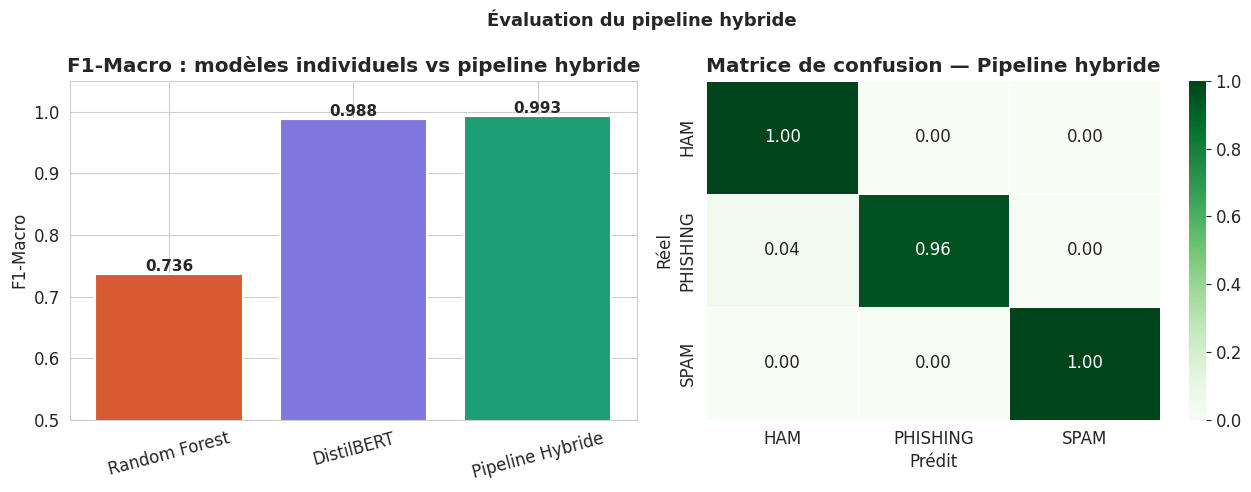

In [13]:
# ---- Visualisation : Comparaison pipeline vs modèles individuels ----

try:
    df_ml_res = pd.read_csv(DATA_DIR / '03_results.csv')
    with open(DATA_DIR / '04_results.json') as f:
        bert_res  = json.load(f)
    has_prev = True
except FileNotFoundError:
    has_prev = False

models_compare = []
if has_prev:
    best_ml_row = df_ml_res.loc[df_ml_res['f1_macro'].idxmax()]
    models_compare += [
        {'name': best_ml_row['model'], 'f1': best_ml_row['f1_macro'], 'color': '#D85A30'},
        {'name': 'DistilBERT',         'f1': bert_res['test_f1_macro'], 'color': '#7F77DD'},
    ]
models_compare.append(
    {'name': 'Pipeline Hybride', 'f1': pipeline_f1, 'color': '#1D9E75'}
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# F1-Macro comparaison
names  = [m['name'] for m in models_compare]
f1s    = [m['f1']   for m in models_compare]
colors = [m['color'] for m in models_compare]

bars = axes[0].bar(names, f1s, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_title('F1-Macro : modèles individuels vs pipeline hybride', fontweight='bold')
axes[0].set_ylabel('F1-Macro')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

# Matrice de confusion pipeline
cm = confusion_matrix(y_true_eval, y_pred_eval, labels=CLASS_NAMES)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=[c.upper() for c in CLASS_NAMES],
            yticklabels=[c.upper() for c in CLASS_NAMES],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Matrice de confusion — Pipeline hybride', fontweight='bold')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')

plt.suptitle('Évaluation du pipeline hybride', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/05_pipeline_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Analyse des niveaux de menace & distribution des alertes

[Pipeline] rules(spam=0.35,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.57) → bert(pred=ham,1.00) → HAM(0.78)
[Pipeline] rules(spam=0.15,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.53) → bert(pred=ham,1.00) → HAM(0.81)
[Pipeline] rules(spam=0.20,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.98) → bert(pred=ham,1.00) → HAM(0.95)
[Pipeline] rules(spam=0.00,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.65) → bert(pred=ham,1.00) → HAM(0.88)
[Pipeline] rules(spam=0.00,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.73) → bert(pred=ham,1.00) → HAM(0.90)
[Pipeline] rules(spam=0.15,phish=0.00) → headers(score=0.00) → ml(pred=phishing,0.98) → bert(pred=phishing,1.00) → PHISHING(0.54)
[Pipeline] rules(spam=0.00,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.92) → bert(pred=ham,1.00) → HAM(0.97)
[Pipeline] rules(spam=0.00,phish=0.00) → headers(score=0.00) → ml(pred=ham,0.84) → bert(pred=ham,1.00) → HAM(0.94)
[Pipeline] rules(spam=0.00,phish=0.00) → headers(score=0.00) → ml

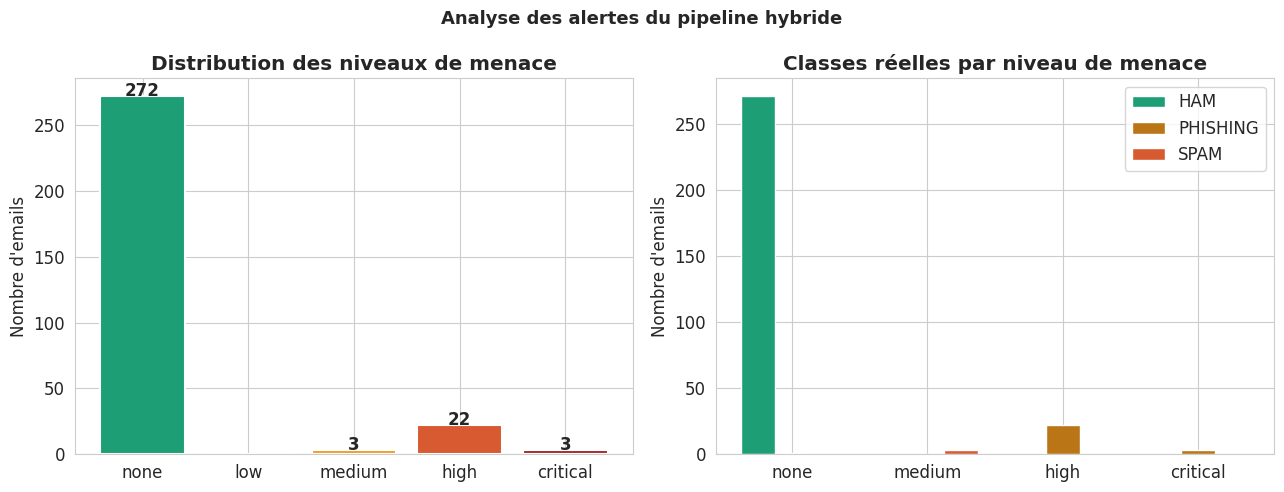

Taux d'alerte global : 9.3% des emails déclenchent une alerte
Emails critiques    : 3 (1.0%)


In [14]:
# Re-collecte des niveaux de menace sur l'échantillon
threat_counts  = {'none': 0, 'low': 0, 'medium': 0, 'high': 0, 'critical': 0}
class_by_threat = {t: [] for t in threat_counts}

for i, (_, row) in enumerate(df_eval.iterrows()):
    r = pipeline.analyze(str(row['text']))
    threat_counts[r.threat_level] += 1
    class_by_threat[r.threat_level].append(row['label'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution des niveaux de menace
threat_colors = {
    'none': '#1D9E75', 'low': '#9FE1CB', 'medium': '#EF9F27',
    'high': '#D85A30', 'critical': '#A32D2D'
}
labels  = list(threat_counts.keys())
counts  = list(threat_counts.values())
tc_colors = [threat_colors[l] for l in labels]

bars = axes[0].bar(labels, counts, color=tc_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution des niveaux de menace', fontweight='bold')
axes[0].set_ylabel('Nombre d\'emails')
for bar, val in zip(bars, counts):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     str(val), ha='center', fontweight='bold')

# Composition de chaque niveau (classes réelles)
threat_class_data = {}
for threat, clss in class_by_threat.items():
    if clss:
        from collections import Counter
        threat_class_data[threat] = Counter(clss)

threats_with_data = [t for t, c in threat_class_data.items() if c]
x_pos = np.arange(len(threats_with_data))
width = 0.25

for j, cls in enumerate(CLASS_NAMES):
    vals = [threat_class_data.get(t, {}).get(cls, 0) for t in threats_with_data]
    axes[1].bar(x_pos + j*width, vals, width,
                label=cls.upper(), color=CLASS_COLORS.get(cls, 'gray'),
                edgecolor='white', linewidth=1)

axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels(threats_with_data)
axes[1].set_title('Classes réelles par niveau de menace', fontweight='bold')
axes[1].set_ylabel('Nombre d\'emails')
axes[1].legend()

plt.suptitle('Analyse des alertes du pipeline hybride', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/05_threat_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Taux d'alerte
total = sum(counts)
alertes = sum(v for k, v in threat_counts.items() if k != 'none')
print(f'Taux d\'alerte global : {alertes/total:.1%} des emails déclenchent une alerte')
print(f'Emails critiques    : {threat_counts["critical"]} ({threat_counts["critical"]/total:.1%})')

## 11. Test de robustesse adversariale (§5.5 du cahier de charges)

In [15]:
# Tests adversariaux : techniques utilisées par les attaquants pour contourner les filtres
ADVERSARIAL_CASES = [
    {
        'attack':     'Obfuscation orthographique',
        'true_label': 'phishing',
        'text':       'Your Micros0ft acc0unt has been susp3nded. V3rify imm3diately: http://m1crosoft-secure.xyz/login'
    },
    {
        'attack':     'Mots légitimes insérés',
        'true_label': 'spam',
        'text':       'Hello friend family love work professional opportunity earn 5000 per week from home guaranteed no experience needed click here'
    },
    {
        'attack':     'URL dans image (texte seul disponible)',
        'true_label': 'phishing',
        'text':       'Dear valued customer, please see the attached image for important account information. Your security is our priority.'
    },
    {
        'attack':     'Phishing HTML avec texte invisible',
        'true_label': 'phishing',
        'text':       'Dear customer\u200b\u200c, your acc\u200bount needs ver\u200cification at http://192.168.1.100/phish'
    },
    {
        'attack':     'Spam pro (investissement)',
        'true_label': 'spam',
        'text':       'I would like to present a confidential investment opportunity with 200% annual returns. Limited to serious investors only. Reply for the prospectus.'
    },
]

print('Tests adversariaux')
print('=' * 70)

adv_results = []
for tc in ADVERSARIAL_CASES:
    r = pipeline.analyze(tc['text'])
    correct = r.predicted_class == tc['true_label']
    sign    = '✓' if correct else '✗'
    adv_results.append(correct)

    print(f'\n  Attaque : {tc["attack"]}')
    print(f'  [{sign}] Réel: {tc["true_label"].upper():10s} | Prédit: {r.predicted_class.upper():10s} | Conf: {r.global_confidence:.2%} | Menace: {r.threat_level}')
    print(f'  Texte : "{tc["text"][:90]}"')
    if r.url_flags:
        print(f'  URL flags : {r.url_flags[:2]}')
    if r.rules_triggered:
        print(f'  Règles    : {[x for x in r.rules_triggered if "invisible" in x or "ip_" in x][:3]}')

adv_acc = sum(adv_results) / len(adv_results)
print(f'\nRobustesse adversariale : {sum(adv_results)}/{len(adv_results)} ({adv_acc:.0%})')
print('Note : les cas "URL dans image" sont une limite connue des systèmes sans OCR.')
print('Solution NB 06 : intégration d\'un module OCR sur les images attachées.')

Tests adversariaux
[Pipeline] rules(spam=0.00,phish=0.25) → headers(score=0.00) → ml(pred=phishing,0.91) → bert(pred=phishing,1.00) → PHISHING(0.57)

  Attaque : Obfuscation orthographique
  [✓] Réel: PHISHING   | Prédit: PHISHING   | Conf: 56.80% | Menace: high
  Texte : "Your Micros0ft acc0unt has been susp3nded. V3rify imm3diately: http://m1crosoft-secure.xyz"
  URL flags : ['suspicious_tld:.xyz']
[Pipeline] rules(spam=0.10,phish=0.00) → headers(score=0.00) → ml(pred=phishing,0.91) → bert(pred=phishing,1.00) → PHISHING(0.52)

  Attaque : Mots légitimes insérés
  [✗] Réel: SPAM       | Prédit: PHISHING   | Conf: 51.89% | Menace: high
  Texte : "Hello friend family love work professional opportunity earn 5000 per week from home guaran"
  Règles    : []
[Pipeline] rules(spam=0.00,phish=0.00) → headers(score=0.00) → ml(pred=phishing,0.73) → bert(pred=phishing,1.00) → HAM(0.55)

  Attaque : URL dans image (texte seul disponible)
  [✗] Réel: PHISHING   | Prédit: HAM        | Conf: 54.55% 

## 12. Sauvegarde du pipeline

In [16]:
# Sauvegarde du pipeline complet (sans les modèles lourds — ceux-ci sont déjà dans data/)
pipeline_config = {
    'weights':             WEIGHTS,
    'thresholds': {
        'early_stop':  THRESHOLD_EARLY_STOP,
        'high':        THRESHOLD_HIGH,
        'medium':      THRESHOLD_MEDIUM,
        'low':         THRESHOLD_LOW,
    },
    'blacklisted_tlds':    list(BLACKLISTED_TLDS),
    'impersonated_brands': IMPERSONATED_BRANDS,
    'spam_keywords':       SPAM_KEYWORDS,
    'phishing_keywords':   PHISHING_KEYWORDS,
    'use_bert':            USE_BERT,
    'class_names':         CLASS_NAMES,
}

# Sauvegarde de la config + du pipeline Python
with open(DATA_DIR / 'pipeline_config.json', 'w') as f:
    json.dump(pipeline_config, f, indent=2)

joblib.dump(pipeline, DATA_DIR / 'pipeline_hybride.pkl')

# Résultats d'évaluation
results_05 = {
    'eval_sample':       EVAL_SAMPLE,
    'pipeline_accuracy': round(pipeline_acc, 4),
    'pipeline_f1_macro': round(pipeline_f1, 4),
    'avg_latency_ms':    round(float(np.mean(latencies)), 2),
    'adversarial_accuracy': round(adv_acc, 4),
    'threat_distribution':  threat_counts,
    'use_bert':          USE_BERT,
    'weights':           WEIGHTS,
}

with open(DATA_DIR / '05_pipeline_results.json', 'w') as f:
    json.dump(results_05, f, indent=2)

print('Artefacts sauvegardés :')
for fname in ['pipeline_hybride.pkl', 'pipeline_config.json',
              '05_pipeline_results.json',
              '05_pipeline_evaluation.png', '05_threat_distribution.png']:
    p = DATA_DIR / fname
    status = '✓' if p.exists() else '✗'
    print(f'  {status} {fname}')

Artefacts sauvegardés :
  ✓ pipeline_hybride.pkl
  ✓ pipeline_config.json
  ✓ 05_pipeline_results.json
  ✓ 05_pipeline_evaluation.png
  ✓ 05_threat_distribution.png


## 13. Résumé final

In [17]:
print('=' * 65)
print('RÉSUMÉ — Notebook 05 : Pipeline Hybride')
print('=' * 65)

print(f'\nArchitecture (4 couches) :')
print(f'  Couche 1 — Règles heuristiques  : {WEIGHTS["rules"]:.0%} du score final')
print(f'  Couche 2 — Analyse headers       : {WEIGHTS["headers"]:.0%} du score final')
print(f'  Couche 3 — Modèle ML (LinearSVC) : {WEIGHTS["ml"]:.0%} du score final')
print(f'  Couche 3b— DistilBERT            : {WEIGHTS["bert"]:.0%} du score final (USE_BERT={USE_BERT})')

print(f'\nPerformances (échantillon {EVAL_SAMPLE} emails) :')
print(f'  Accuracy        : {pipeline_acc:.4f}')
print(f'  F1-Macro        : {pipeline_f1:.4f}')
print(f'  Latence moyenne : {np.mean(latencies):.1f} ms/email')
print(f'  Robustesse adv. : {adv_acc:.0%} ({sum(adv_results)}/{len(adv_results)} attaques détectées)')

print(f'\nLimites identifiées :')
print('  - URLs cachées dans des images (sans OCR) : non détectables par le texte')
print('  - Phishing social engineering sans URL : confiance plus faible')
print('  - Headers SPF/DKIM absents : couche 2 moins discriminante')

print(f'\nFonctionnalités couvertes (cahier de charges) :')
print('  ✓ §5.4  Architecture hybride règles + ML')
print('  ✓ §6.1  Analyse avancée structure des messages (headers)')
print('  ✓ §6.2  Détection spoofing (SPF/DKIM/DMARC + mismatch domaine)')
print('  ✓ §6.4  Score de confiance + niveau de menace par email')
print('  ✓ §5.5  Tests adversariaux')

print(f'\nProchain notebook :')
print('  NB 06 — API REST (FastAPI) + déploiement Docker + rapport final')

RÉSUMÉ — Notebook 05 : Pipeline Hybride

Architecture (4 couches) :
  Couche 1 — Règles heuristiques  : 20% du score final
  Couche 2 — Analyse headers       : 25% du score final
  Couche 3 — Modèle ML (LinearSVC) : 35% du score final
  Couche 3b— DistilBERT            : 20% du score final (USE_BERT=True)

Performances (échantillon 300 emails) :
  Accuracy        : 0.9967
  F1-Macro        : 0.9929
  Latence moyenne : 83.9 ms/email
  Robustesse adv. : 40% (2/5 attaques détectées)

Limites identifiées :
  - URLs cachées dans des images (sans OCR) : non détectables par le texte
  - Phishing social engineering sans URL : confiance plus faible
  - Headers SPF/DKIM absents : couche 2 moins discriminante

Fonctionnalités couvertes (cahier de charges) :
  ✓ §5.4  Architecture hybride règles + ML
  ✓ §6.1  Analyse avancée structure des messages (headers)
  ✓ §6.2  Détection spoofing (SPF/DKIM/DMARC + mismatch domaine)
  ✓ §6.4  Score de confiance + niveau de menace par email
  ✓ §5.5  Tests ad